This notebook contains the main model for the project. 
The idea is to create a machine learning model for a time series, taht predicts the temperature for a few days. 

The data is the measurements of the temperature and the incoming solar irradiance in an hourly-mean from the weather station at the UniSport in Cologne. The measurement periods were March, April, May of the years, 2024, 2025 and 2026. It was preprocessed from 10min mean to one hour mean and to have only the temperature and the radiation data. 


In [1]:
!pip3 install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import the needed modules

import pandas as pd 
import numpy as np 
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pickle 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import random
from sklearn.preprocessing import StandardScaler

In [3]:
# Read in the preprocessed data

df=pd.read_csv('data_processed.csv', parse_dates=['TIMESTAMP'])

df

,TIMESTAMP,AirTC_2_Avg,SWUpper_Avg
0,2024-03-01 00:00:00,7.202200,0.000000
1,2024-03-01 01:00:00,6.842833,0.000000
2,2024-03-01 02:00:00,6.663333,0.000000
3,2024-03-01 03:00:00,7.020667,0.000000
4,2024-03-01 04:00:00,7.263167,0.000000
...,...,...,...
6621,2026-05-31 19:00:00,20.578333,4.426333
6622,2026-05-31 20:00:00,19.611667,0.000000
6623,2026-05-31 21:00:00,18.628333,0.000000
6624,2026-05-31 22:00:00,17.856667,0.000000


In [4]:
#define the randomness, so that we always have the same results

seed=23

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic=True


In [5]:
#normalize data

scale=MinMaxScaler()

df[['AirTC_2_Avg', 'SWUpper_Avg']]=scale.fit_transform(df[['AirTC_2_Avg', 'SWUpper_Avg']])

with open ('scale.pkl', 'wb') as f:
    pickle.dump(scale, f)
 

print(df[['AirTC_2_Avg', 'SWUpper_Avg']].describe())

       AirTC_2_Avg  SWUpper_Avg
count  6626.000000  6626.000000
mean      0.408224     0.179819
std       0.166296     0.253787
min       0.000000     0.000000
25%       0.286057     0.000000
50%       0.395750     0.029450
75%       0.515576     0.302490
max       1.000000     1.000000


In [6]:
#split the data in train und test data

train=df[df['TIMESTAMP'].dt.year.isin([2024, 2025])]
test= df[df['TIMESTAMP'].dt.year==2026]

print(len(train))
print(len(test))

4418
2208


In [7]:
#sliding window

window_size=24  #size of the window
 
def sequences(data):
    X, y=[],[]
    values=data[['AirTC_2_Avg','SWUpper_Avg']].values

    for i in range(len(values)-window_size):
        X.append(values[i:i+window_size])
        y.append(values[i+window_size][0])

    return np.array(X), np.array(y)

X_train, y_train= sequences(train)
X_test, y_test=sequences(test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)



(4394, 24, 2)
(4394,)
(2184, 24, 2)
(2184,)


In [8]:
class WeatherData(Dataset):
    def __init__(self, X, y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)

    def __len__(self):
        return(len(self.X))
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

train_dataset=WeatherData(X_train, y_train)
test_dataset=WeatherData(X_test, y_test)

batch_size=32

train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(test_loader))
print(len(train_loader))


69
138


In [9]:
class FFN(nn.Module):
    def __init__(self):
        super (FFN, self).__init__()

        self.model=nn.Sequential(nn.Linear(24*2,64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    
    def forward(self,x):
        x=x.view(x.size(0),-1)
        return self.model(x).squeeze(1)
    

model=FFN()
print(model)


FFN(
  (model): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [10]:
crit=nn.MSELoss() #mean squared-error--> how 'wrong' is model?

optimizer=optim.Adam(model.parameters(), lr=0.001)  #learning rate


run=50 #

for r in range(run):
    model.train()
    total_loss=0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions=model(X_batch)
        loss=crit(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    if (r+1)%10==0:
        print((r+1)/run, avg_loss)


0.2 0.0006074162266104131
0.4 0.0005174044571754496
0.6 0.0004499292429671555
0.8 0.00040617127988430116
1.0 0.00042312327317684293


## Comparing the model results with the measurements

In [11]:
model.eval()
predictions=[]
actuals=[]

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred=model(X_batch)
        predictions.extend(pred.numpy())
        actuals.extend(y_batch.numpy())


predictions=np.array(predictions)
actuals=np.array(actuals)


#Mean Absolute error
mae=np.mean(np.abs(predictions-actuals))

#Mean squared error
mse=np.mean((predictions-actuals)**2)


print(f'MAE: {mae}')
print(f'MSE: {mse}')


MAE: 0.014863315038383007
MSE: 0.00038322695763781667


In [12]:
# now convert back to °C for an easier interpretation

with open('scale.pkl', 'rb') as f:
    scale=pickle.load(f)

#transform predictions and measurements back
pred_rescaled=scale.inverse_transform(np.column_stack([predictions, np.zeros(len(predictions))]))[:,0]

actual_rescaled=scale.inverse_transform(np.column_stack([actuals, np.zeros(len(actuals))]))[:,0]



#Error in °C
mae_c=np.mean(np.abs(pred_rescaled-actual_rescaled))
mse_c=np.mean((pred_rescaled-actual_rescaled)**2)
rmse_c=np.sqrt(mse_c) #root mean squared error


print(f'MAE: {mae_c} °C')
print(f'MSE: {mse_c} °C')
print(f'RMSE: {rmse_c} °C')

MAE: 0.4932712732063235 °C
MSE: 0.4220815954027928 °C
RMSE: 0.6496780705878819 °C


<function matplotlib.pyplot.show(close=None, block=None)>

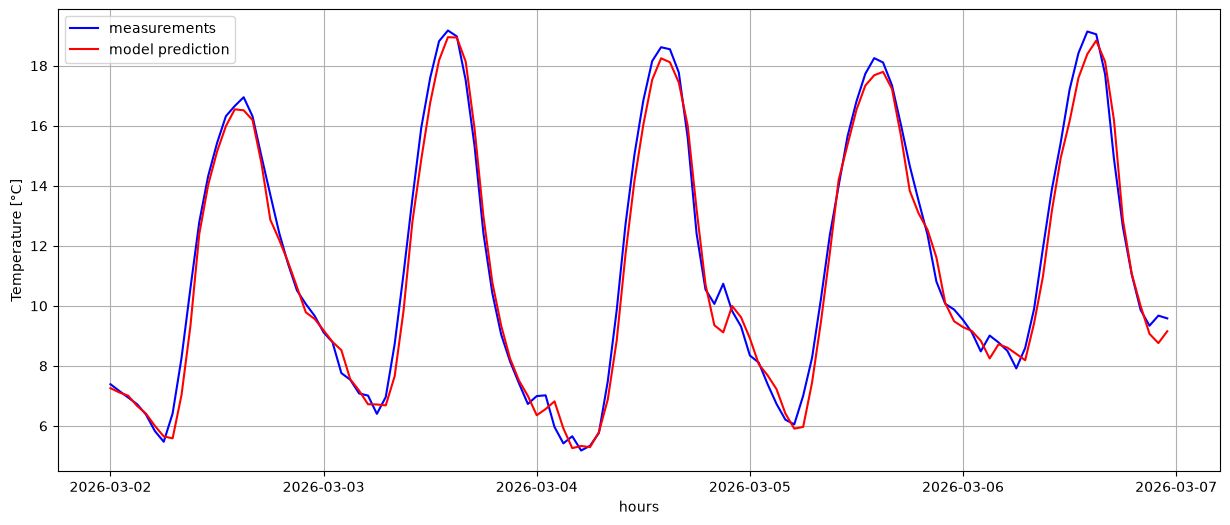

In [13]:
#plot the model forecast vs the real measurements for specific days to see the differences

#for better visualisation: real dates instead of hours
test_timestamps = test['TIMESTAMP'].iloc[window_size:].values


# first:  5 days in a row = 120 hours, starting on first model data
n=120


plt.figure(figsize=(15, 6))
plt.plot(test_timestamps[:n], actual_rescaled[:n], label='measurements', color='blue') #unit: °C
plt.plot(test_timestamps[:n],pred_rescaled [:n], label='model prediction', color='red')
plt.xlabel('hours')
plt.ylabel('Temperature [°C]')
plt.legend()
plt.grid()
plt.show




In [36]:
#Lets go into detail, an look, which dates (per day) were quite good predicted and which ones not:

#build Dataframe
results=pd.DataFrame({'timestamp':test_timestamps, 'measurements':actual_rescaled, 'model prediction':pred_rescaled, 'error absolute':np.abs(pred_rescaled-actual_rescaled)})

#date as own coloumn

results['date']=pd.to_datetime(results['timestamp']).dt.date

#define threshold for good predicitons. above, the predicitons are too far away from measurements
threshold=0.5 #unit:°C

daily=results.groupby('date').agg(
    mae=('error absolute', 'mean'),  #mean error
    mse= ("error absolute", lambda x: np.mean(x**2)),  #mean squared error
    rmse= ("error absolute", lambda x: np.sqrt(np.mean(x**2))),
    max_error=('error absolute', 'max'), #biggest error
    good_pred=('error absolute', lambda x: (x<threshold).sum()), #amount of 'good' predictions
    number_pred=('error absolute', 'count')) #number of predicitions, should be 24 -> 24 hours a day
    

daily['accuracy']=(daily['good_pred']/daily['number_pred']*100).round(2)

print(daily)


                 mae       mse      rmse  max_error  good_pred  number_pred  \
date                                                                          
2026-03-02  0.326190  0.226394  0.475808   1.258126         20           24   
2026-03-03  0.440482  0.321630  0.567124   1.230926         14           24   
2026-03-04  0.554441  0.437020  0.661075   1.619585         13           24   
2026-03-05  0.422163  0.251209  0.501208   1.035717         16           24   
2026-03-06  0.486550  0.353502  0.594561   1.290068         15           24   
...              ...       ...       ...        ...        ...          ...   
2026-05-27  0.417596  0.229981  0.479563   1.265209         17           24   
2026-05-28  0.499048  0.357518  0.597928   1.108040         12           24   
2026-05-29  0.805955  0.943963  0.971578   2.177861          8           24   
2026-05-30  0.673207  0.648637  0.805380   1.479980          9           24   
2026-05-31  0.439732  0.253460  0.503448   0.944878 

In [37]:
#Maximum and Minimum of the accuracy -> which 3 days were predicted best and worst, respectively

max_days=daily.nlargest(3, 'accuracy')
min_days=daily.nsmallest(3, 'accuracy')



print('Best days:')
print(max_days)
print('Worst days:')
print(min_days)




Best days:
                 mae       mse      rmse  max_error  good_pred  number_pred  \
date                                                                          
2026-05-06  0.273301  0.091325  0.302200   0.520137         23           24   
2026-05-15  0.266668  0.095664  0.309295   0.685473         22           24   
2026-04-13  0.260992  0.116430  0.341219   0.884888         21           24   

            accuracy  
date                  
2026-05-06     95.83  
2026-05-15     91.67  
2026-04-13     87.50  
Worst days:
                 mae       mse      rmse  max_error  good_pred  number_pred  \
date                                                                          
2026-03-27  0.650783  0.534159  0.730862   1.262255          8           24   
2026-04-22  0.759195  0.965438  0.982567   2.737913          8           24   
2026-05-12  0.698739  0.734962  0.857299   2.391903          8           24   

            accuracy  
date                  
2026-03-27     33.33  
2

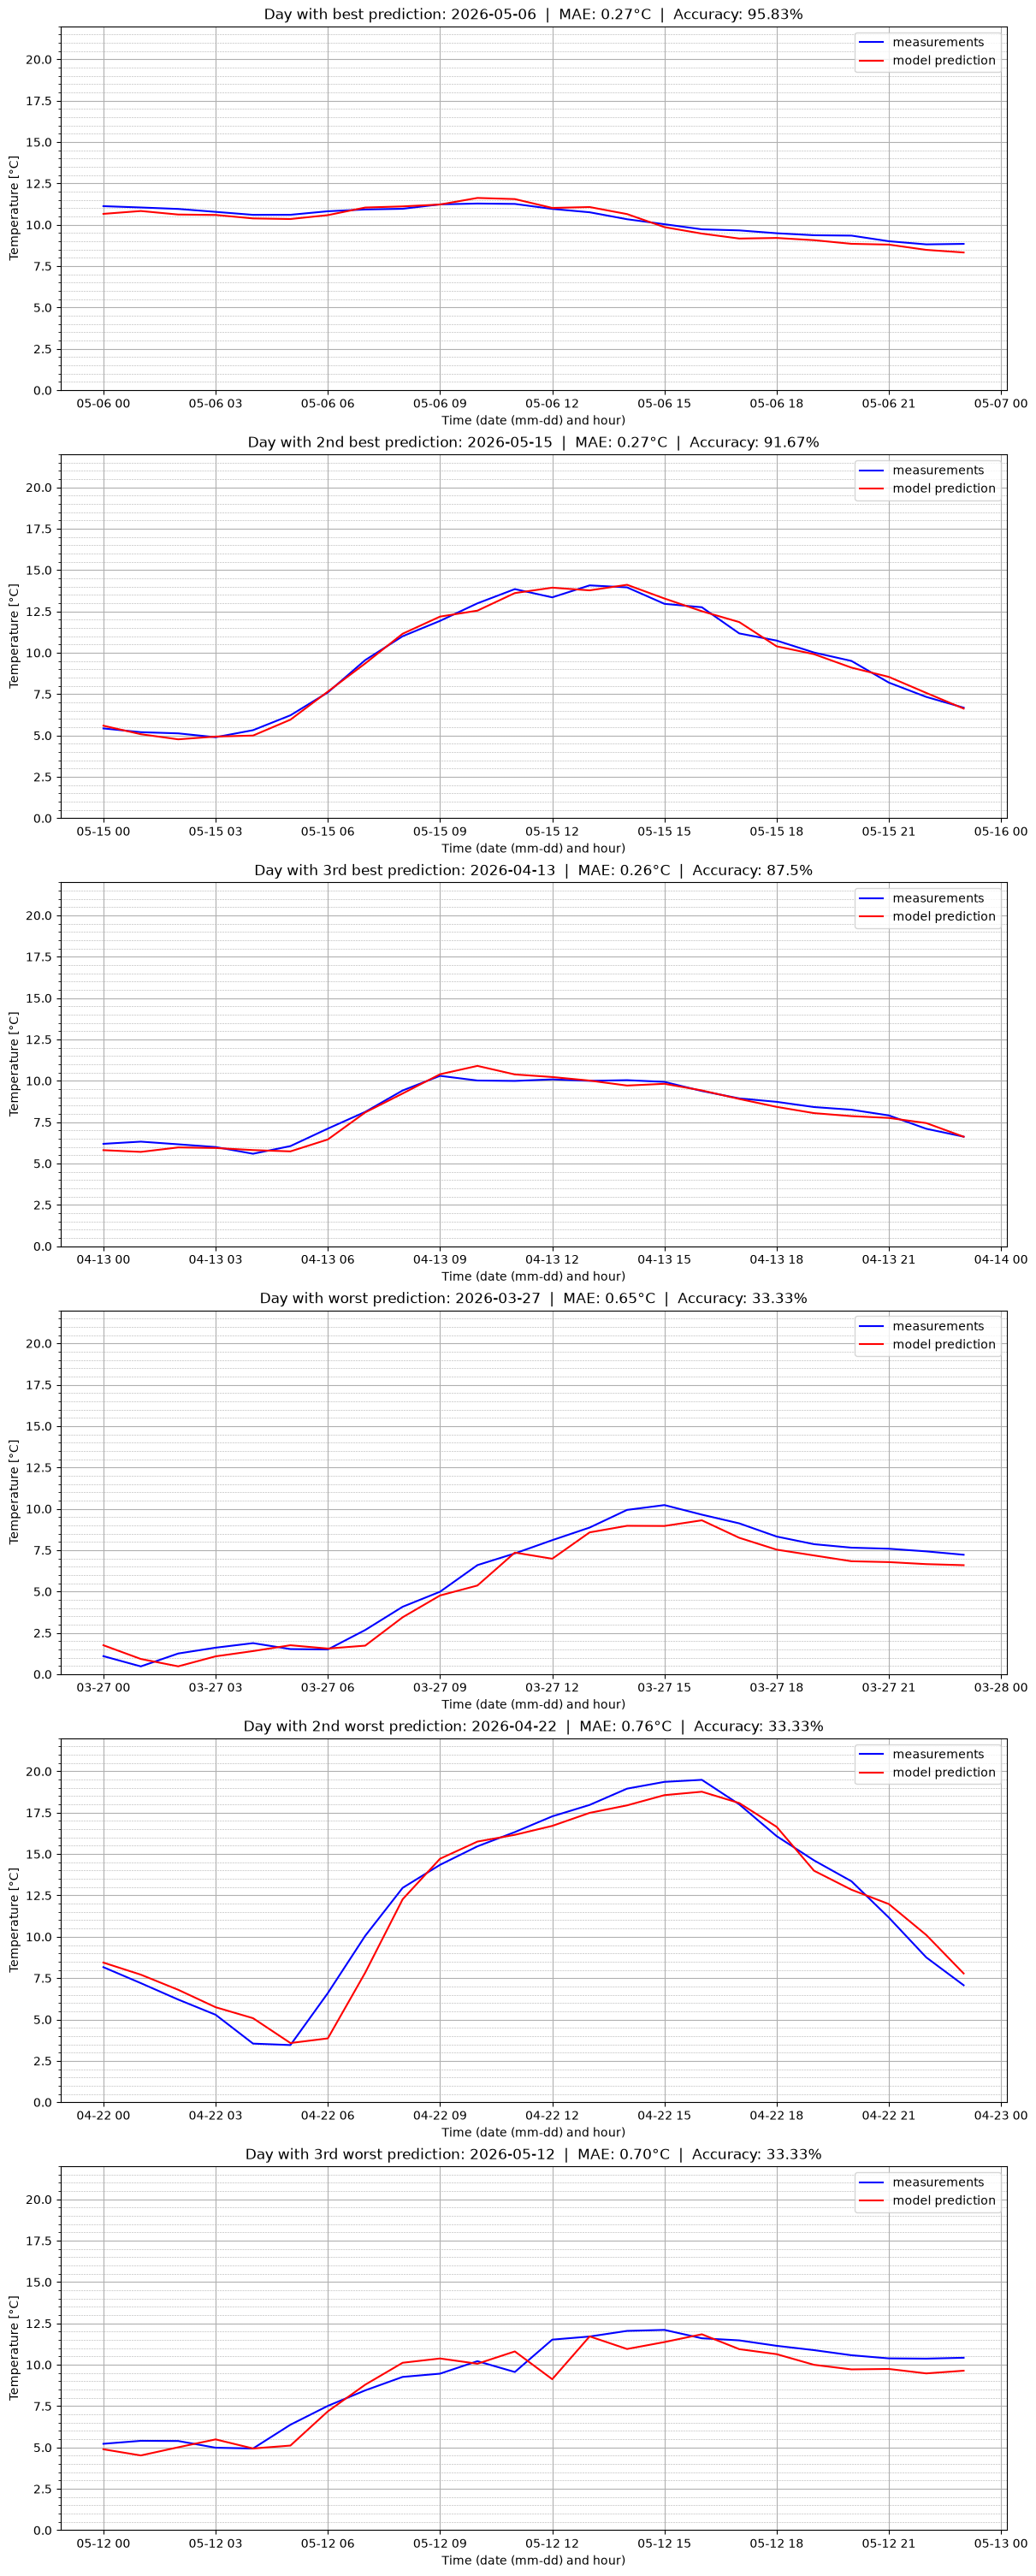

In [38]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(12, 30), constrained_layout=True)

# Beste 3 Tage
for ax, (date, row), title in zip(
    [ax1, ax2, ax3],
    max_days.iterrows(),
    ["Day with best prediction", "Day with 2nd best prediction", "Day with 3rd best prediction"]
):
    mask     = results["date"] == date
    day_data = results[mask]

    ax.plot(day_data["timestamp"], day_data["measurements"],     label="measurements",    color="blue")
    ax.plot(day_data["timestamp"], day_data["model prediction"], label="model prediction", color="red")
    ax.set_xlabel("Time (date (mm-dd) and hour)")
    ax.set_ylabel("Temperature [°C]")
    ax.set_ylim(0, 22 )
    ax.set_title(f"{title}: {date}  |  MAE: {row['mae']:.2f}°C  |  Accuracy: {row['accuracy']}%")
    ax.legend()
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.grid(True, which="major", linestyle="-",  linewidth=0.8)
    ax.grid(True, which="minor", linestyle="--", linewidth=0.4)

# Schlechteste 3 Tage
for ax, (date, row), title in zip(
    [ax4, ax5, ax6],
    min_days.iterrows(),
    ["Day with worst prediction", "Day with 2nd worst prediction", "Day with 3rd worst prediction"]
):
    mask     = results["date"] == date
    day_data = results[mask]

    ax.plot(day_data["timestamp"], day_data["measurements"],     label="measurements",    color="blue")
    ax.plot(day_data["timestamp"], day_data["model prediction"], label="model prediction", color="red")
    ax.set_xlabel("Time (date (mm-dd) and hour)")
    ax.set_ylabel("Temperature [°C]")
    ax.set_title(f"{title}: {date}  |  MAE: {row['mae']:.2f}°C  |  Accuracy: {row['accuracy']}%")
    ax.set_ylim(0, 22)
    ax.legend()
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.grid(True, which="major", linestyle="-",  linewidth=0.8) 
    ax.grid(True, which="minor", linestyle="--", linewidth=0.4)

plt.show()

In [ ]:
#now lets look, if the predicition if the night or of the day is better
#Divide the day: daytime: 7am to 8 pm, nighttime: 8pm to 7am

#extract gour from timestamp
results['hour']=pd.to_datetime(results['timestamp']).dt.hour


results['period']=results['hour'].apply(lambda h:'day' if 7<=h<20 else 'night')

period_analysis = results.groupby('period').agg(
    mae=('error absolute', 'mean'),
    mse= ("error absolute", lambda x: np.mean(x**2)), 
    rmse= ("error absolute", lambda x: np.sqrt(np.mean(x**2))),
    max_error=('error absolute', 'max'),
    good_pred=('error absolute', lambda x: (x<threshold).sum()), 
    number_pred=('error absolute', 'count')
).reset_index()


period_analysis['accuracy']=(period_analysis['good_pred']/period_analysis['number_pred']*100).round(2)


print(period_analysis)

  period       mae       mse      rmse  max_error  good_pred  number_pred  \
0    day  0.550318  0.509985  0.714132   4.581224        640         1183   
1  night  0.425853  0.318196  0.564088   2.749774        665         1001   

   accuracy  
0     54.10  
1     66.43  


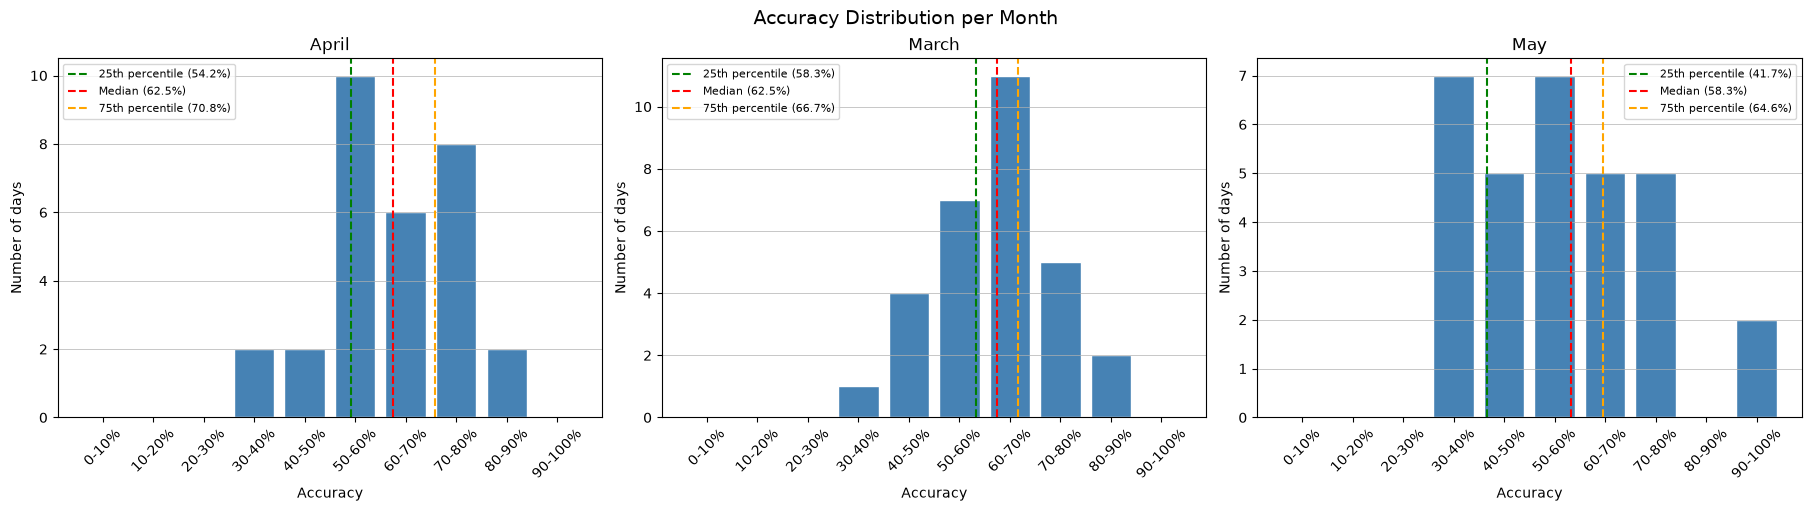

In [18]:
#monthly frequency distribution

daily["month"] = pd.to_datetime(daily.index).month
daily['month_name']=daily['month'].map({3:'March', 4:'April', 5:'May'})

#define accuracy bins
bins   = list(range(0, 110, 10))
labels = [f"{i}-{i+10}%" for i in range(0, 100, 10)]

daily["accuracy_bin"] = pd.cut(daily["accuracy"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (month_name, group) in zip(axes, daily.groupby("month_name")):
    counts = group["accuracy_bin"].value_counts().reindex(labels, fill_value=0)
    ax.bar(labels, counts, color="steelblue", edgecolor="white")

    # Perzentile berechnen
    p25 = group["accuracy"].quantile(0.25)
    p50 = group["accuracy"].quantile(0.50)
    p75 = group["accuracy"].quantile(0.75)

    # Vertikale Linien – müssen auf Bin-Position gemappt werden
    for p, color, label in zip(
        [p25, p50, p75],
        ["green", "red", "orange"],
        [f"25th percentile ({p25:.1f}%)", f"Median ({p50:.1f}%)", f"75th percentile ({p75:.1f}%)"]
    ):
        # Bin-Position berechnen (jeder Bin ist 10% breit)
        bin_pos = p / 10 - 0.5  # Mitte des jeweiligen Bins
        ax.axvline(x=bin_pos, color=color, linestyle="--", linewidth=1.5, label=label)

    ax.set_title(month_name)
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Number of days")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", linewidth=0.5)
    ax.legend(fontsize=8)

plt.suptitle("Accuracy Distribution per Month", fontsize=14)
plt.show()


## Ablation study

In this ablation study, the radiation input gets randomised to see, what impact this inputs has to our model prediction for the temperature. 



In [44]:
#Copy the test data
X_test_ablation=X_test.copy()

#replace radiation values with random values 
#Gaußiand distribution as the radiation values
rad_mean=X_test[:,:,1].mean()
rad_std=X_test[:,:,1].std()

np.random.seed(42)
X_test_ablation[:,:,1] = np.random.normal(loc=rad_mean, scale=rad_std, size=X_test[:, :, 1].shape).clip(0, 1)  #[0,1], because normalized

# Inference with random data
model.eval()
predictions_ablation = []

with torch.no_grad():
    for i in range(0, len(X_test_ablation), 32):
        batch=torch.tensor(X_test_ablation[i:i+32], dtype=torch.float32)
        pred=model(batch)
        predictions_ablation.extend(pred.numpy())

predictions_ablation=np.array(predictions_ablation)

#go back to °C
pred_ablation_rescaled = scale.inverse_transform(
    np.column_stack([predictions_ablation, np.zeros(len(predictions_ablation))]))[:, 0]

#Compare the results with the real measurements
mae_normal=np.mean(np.abs(pred_rescaled-actual_rescaled))
mae_ablation=np.mean(np.abs(pred_ablation_rescaled-actual_rescaled))

mse_normal=np.mean((pred_rescaled-actual_rescaled)**2)
mse_ablation=np.mean((pred_ablation_rescaled-actual_rescaled)**2)

rmse_normal=np.sqrt(mse_normal)
rmse_ablation=np.sqrt(mse_ablation)




print(f"MAE with measurement data: {mae_normal:.2f} °C")
print(f"MAE with random radiation: {mae_ablation:.2f} °C")


print(f"Difference: {mae_ablation-mae_normal:.2f} °C")

print(f"{'':20} {'Measurement':>10} {'Random':>10} {'Difference':>10}")
print(f"{'MAE (°C)':20} {mae_normal:>10.2f} {mae_ablation:>10.2f} {mae_ablation - mae_normal:>+10.2f}")
print(f"{'MSE (°C)':20} {mse_normal:>10.2f} {mse_ablation:>10.2f} {mse_ablation - mse_normal:>+10.2f}")
print(f"{'RMSE (°C)':20} {rmse_normal:>10.2f} {rmse_ablation:>10.2f} {rmse_ablation - rmse_normal:>+10.2f}")

MAE with measurement data: 0.49 °C
MAE with random radiation: 1.20 °C
Difference: 0.71 °C
                     Measurement     Random Difference
MAE (°C)                   0.49       1.20      +0.71
MSE (°C)                   0.42       2.23      +1.81
RMSE (°C)                  0.65       1.49      +0.84
